In [44]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [45]:
df = pd.read_csv('/Users/sanskargupta/Documents/Programming /Projects/Employee Retention Prediction Platform/dataset/hr_attrition_encoded.csv')

In [46]:
df.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Attrition
0,41,1102,1,2,2,0,94,3,2,4,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1
1,49,279,8,1,3,1,61,2,2,2,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0
2,37,1373,2,2,4,1,92,2,1,3,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1
3,33,1392,3,4,4,0,56,3,1,3,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0
4,27,591,2,1,1,1,40,3,1,2,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0


In [47]:
df.columns

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate',
       'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Department_Research & Development',
       'Department_Sales', 'EducationField_Life Sciences',
       'EducationField_Marketing', 'EducationField_Medical',
       'EducationField_Other', 'EducationField_Technical Degree',
       'JobRole_Human Resources', 'JobRole_Laboratory Technician',
       'JobRole_Manager', 'JobRole_Manufacturing Director',
       'JobRole_Research Director', 'JobRole_Research Scientist',
       'JobRole_Sales Executive', 'JobRole_Sales Representative

In [48]:
X = df.drop("Attrition", axis=1)

In [49]:
y = df['Attrition']

In [50]:
print(X.shape)
print(y.shape)

(1470, 44)
(1470,)


In [51]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [52]:
print(X_train.shape)
print(X_test.shape)
print("\nTraining Target Distribution")
print(y_train.value_counts(normalize=True))
print("\nTesting Target Distribution")
print(y_test.value_counts(normalize=True))

(1176, 44)
(294, 44)

Training Target Distribution
Attrition
0    0.838435
1    0.161565
Name: proportion, dtype: float64

Testing Target Distribution
Attrition
0    0.840136
1    0.159864
Name: proportion, dtype: float64


In [53]:
print([df.nunique().sort_values()])

[Attrition                               2
JobRole_Laboratory Technician           2
JobRole_Human Resources                 2
EducationField_Technical Degree         2
EducationField_Other                    2
EducationField_Medical                  2
EducationField_Marketing                2
EducationField_Life Sciences            2
Department_Sales                        2
Department_Research & Development       2
BusinessTravel_Travel_Rarely            2
JobRole_Research Director               2
JobRole_Research Scientist              2
JobRole_Manager                         2
PerformanceRating                       2
JobRole_Manufacturing Director          2
OverTime                                2
BusinessTravel_Travel_Frequently        2
MaritalStatus_Single                    2
JobRole_Sales Executive                 2
JobRole_Sales Representative            2
Gender                                  2
MaritalStatus_Married                   2
RelationshipSatisfaction         

In [54]:
num_cols = [
    'Age',
    'DailyRate',
    'DistanceFromHome',
    'HourlyRate',
    'MonthlyIncome',
    'MonthlyRate',
    'NumCompaniesWorked',
    'PercentSalaryHike',
    'TotalWorkingYears',
    'TrainingTimesLastYear',
    'YearsAtCompany',
    'YearsInCurrentRole',
    'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]

In [55]:
X_train.columns

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate',
       'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Department_Research & Development',
       'Department_Sales', 'EducationField_Life Sciences',
       'EducationField_Marketing', 'EducationField_Medical',
       'EducationField_Other', 'EducationField_Technical Degree',
       'JobRole_Human Resources', 'JobRole_Laboratory Technician',
       'JobRole_Manager', 'JobRole_Manufacturing Director',
       'JobRole_Research Director', 'JobRole_Research Scientist',
       'JobRole_Sales Executive', 'JobRole_Sales Representative

In [56]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [57]:
from sklearn.linear_model import LogisticRegression
regressor = LogisticRegression(random_state=42,max_iter=1000)

In [58]:
regressor.fit(X_train,y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [59]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,roc_curve,confusion_matrix

In [60]:
y_pred = regressor.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print('accuracy',accuracy)
print('precision',precision)
print('recall',recall)
print('f1 score',f1)
print('confusion matrix',cm)

accuracy 0.8639455782312925
precision 0.64
recall 0.3404255319148936
f1 score 0.4444444444444444
confusion matrix [[238   9]
 [ 31  16]]


In [61]:
y_prob = regressor.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_prob)
print(roc_auc)

0.8111809802739255


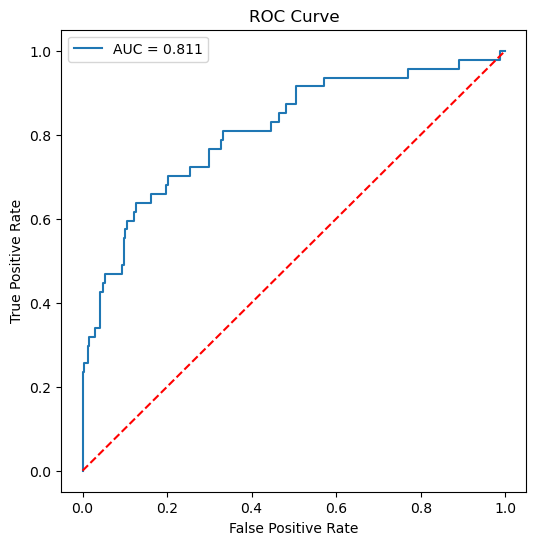

In [62]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='red')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [63]:
#using class weights
regressor=LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

In [64]:
regressor.fit(X_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [65]:
print(y_test.value_counts())

Attrition
0    247
1     47
Name: count, dtype: int64


In [66]:
y_pred = regressor.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print('accuracy',accuracy)
print('precision',precision)
print('recall',recall)
print('f1 score',f1)
print('confusion matrix',cm)

accuracy 0.7551020408163265
precision 0.3563218390804598
recall 0.6595744680851063
f1 score 0.4626865671641791
confusion matrix [[191  56]
 [ 16  31]]


In [67]:
y_prob = regressor.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_prob)
print(roc_auc)

0.8035145146007409


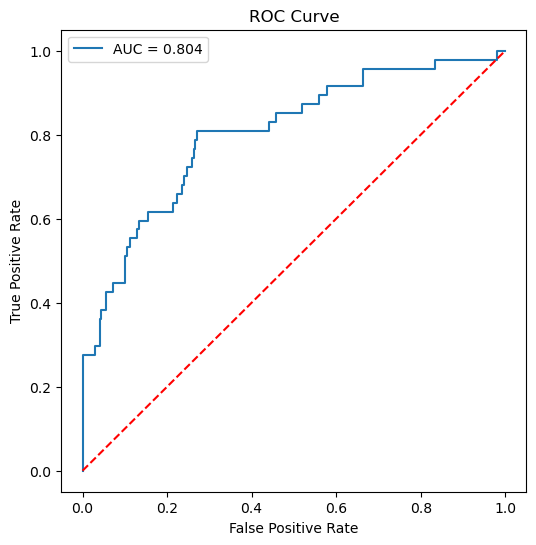

In [68]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='red')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [69]:
regressor = LogisticRegression(max_iter=1000,random_state=42)
param_grid = [

    {
        'solver':['lbfgs'],
        'penalty':['l2'],
        'C':[0.01,0.1,1,10,100],
        'class_weight':[None,'balanced']
    },

    {
        'solver':['liblinear'],
        'penalty':['l1','l2'],
        'C':[0.01,0.1,1,10,100],
        'class_weight':[None,'balanced']
    },

    {
        'solver':['saga'],
        'penalty':['l1','l2'],
        'C':[0.01,0.1,1,10,100],
        'class_weight':[None,'balanced']
    },

    {
        'solver':['saga'],
        'penalty':['elasticnet'],
        'l1_ratio':[0.2,0.5,0.8],
        'C':[0.01,0.1,1,10,100],
        'class_weight':[None,'balanced']
    }

]

In [70]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(
    estimator=regressor,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=2
)

In [71]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 80 candidates, totalling 400 fits
[CV] END C=0.01, class_weight=None, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END C=0.01, class_weight=None, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END C=0.01, class_weight=None, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END C=0.01, class_weight=None, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END C=0.01, class_weight=balanced, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END C=0.01, class_weight=balanced, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END C=0.01, class_weight=balanced, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END C=0.01, class_weight=balanced, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END .C=0.1, class_weight=None, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END .C=0.1, class_weight=None, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END .C=0.1, class_weight=None, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END .C=0.1, class_weight=N

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END ..C=100, class_weight=None, penalty=l2, solver=saga; total time=   0.3s
[CV] END C=1, class_weight=balanced, penalty=l1, solver=saga; total time=   0.1s
[CV] END C=1, class_weight=balanced, penalty=l2, solver=saga; total time=   0.1s
[CV] END C=0.1, class_weight=balanced, penalty=l2, solver=saga; total time=   0.1s
[CV] END C=100, class_weight=balanced, penalty=l1, solver=liblinear; total time=   0.5s
[CV] END C=0.01, class_weight=None, l1_ratio=0.2, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END ...C=10, class_weight=None, penalty=l1, solver=saga; total time=   0.3s
[CV] END C=0.01, class_weight=None, l1_ratio=0.2, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END ....C=1, class_weight=None, penalty=l1, solver=saga; total time=   0.3s
[CV] END C=1, class_weight=balanced, penalty=l1, solver=saga; total time=   0.2s
[CV] END C=10, class_weight=balanced, penalty=l2, solver=saga; total time=   0.3s
[CV] END C=0.01, class_weight=None, l1_ratio=0.2, penalty

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END C=0.01, class_weight=None, l1_ratio=0.5, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=100, class_weight=balanced, penalty=l1, solver=saga; total time=   0.4s
[CV] END ..C=100, class_weight=None, penalty=l2, solver=saga; total time=   0.3s
[CV] END C=10, class_weight=balanced, penalty=l1, solver=saga; total time=   0.4s
[CV] END ....C=1, class_weight=None, penalty=l1, solver=saga; total time=   0.1s
[CV] END C=0.01, class_weight=None, l1_ratio=0.5, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=0.01, class_weight=None, l1_ratio=0.5, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=0.01, class_weight=None, l1_ratio=0.5, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=1, class_weight=balanced, penalty=l1, solver=saga; total time=   0.2s
[CV] END C=0.01, class_weight=None, l1_ratio=0.5, penalty=elasticnet, solver=saga; total time=   0.0s
[CV] END C=0.01, class_weight=None, l1_ratio=0.8, penalty=elasticnet, solver=saga;

...

[CV] END C=100, class_weight=None, l1_ratio=0.8, penalty=elasticnet, solver=saga; total time=   0.4s
[CV] END C=100, class_weight=None, l1_ratio=0.8, penalty=elasticnet, solver=saga; total time=   0.4s
[CV] END C=100, class_weight=balanced, l1_ratio=0.2, penalty=elasticnet, solver=saga; total time=   0.4s
[CV] END C=100, class_weight=balanced, l1_ratio=0.2, penalty=elasticnet, solver=saga; total time=   0.4s
[CV] END C=100, class_weight=balanced, l1_ratio=0.2, penalty=elasticnet, solver=saga; total time=   0.4s
[CV] END C=100, class_weight=balanced, l1_ratio=0.2, penalty=elasticnet, solver=saga; total time=   0.4s
[CV] END C=100, class_weight=balanced, l1_ratio=0.2, penalty=elasticnet, solver=saga; total time=   0.4s


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max

[CV] END C=100, class_weight=balanced, l1_ratio=0.5, penalty=elasticnet, solver=saga; total time=   0.4s
[CV] END C=100, class_weight=balanced, l1_ratio=0.5, penalty=elasticnet, solver=saga; total time=   0.4s
[CV] END C=100, class_weight=balanced, l1_ratio=0.5, penalty=elasticnet, solver=saga; total time=   0.3s
[CV] END C=100, class_weight=balanced, l1_ratio=0.5, penalty=elasticnet, solver=saga; total time=   0.4s
[CV] END C=100, class_weight=balanced, l1_ratio=0.5, penalty=elasticnet, solver=saga; total time=   0.4s
[CV] END C=100, class_weight=balanced, l1_ratio=0.8, penalty=elasticnet, solver=saga; total time=   0.4s
[CV] END C=100, class_weight=balanced, l1_ratio=0.8, penalty=elasticnet, solver=saga; total time=   0.4s
[CV] END C=100, class_weight=balanced, l1_ratio=0.8, penalty=elasticnet, solver=saga; total time=   0.3s
[CV] END C=100, class_weight=balanced, l1_ratio=0.8, penalty=elasticnet, solver=saga; total time=   0.3s
[CV] END C=100, class_weight=balanced, l1_ratio=0.8, pe

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, random_state=42),
             n_jobs=-1,
             param_grid=[{'C': [0.01, 0.1, 1, 10, 100],
                          'class_weight': [None, 'balanced'], 'penalty': ['l2'],
                          'solver': ['lbfgs']},
                         {'C': [0.01, 0.1, 1, 10, 100],
                          'class_weight': [None, 'balanced'],
                          'penalty': ['l1', 'l2'], 'solver': ['liblinear']},
                         {'C': [0.01, 0.1, 1, 10, 100],
                          'class_weight': [None, 'balanced'],
                          'penalty': ['l1', 'l2'], 'solver': ['saga']},
                         {'C': [0.01, 0.1, 1, 10, 100],
                          'class_weight': [None, 'balanced'],
                          'l1_ratio': [0.2, 0.5, 0.8],
                          'penalty': ['elasticnet'], 'solver': ['saga']}],
             scoring='f1', verbose=2)

In [72]:
best_model=grid.best_estimator_
print(grid.best_params_)
print(grid.best_score_)

{'C': 1, 'class_weight': None, 'l1_ratio': 0.2, 'penalty': 'elasticnet', 'solver': 'saga'}
0.5561834775394097


In [73]:
y_pred = best_model.predict(X_test)

In [74]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.8605442176870748
Precision: 0.6153846153846154
Recall: 0.3404255319148936
F1: 0.4383561643835616


In [75]:
import pickle

with open("/Users/sanskargupta/Documents/Programming /Projects/Employee Retention Prediction Platform/model/best_model.pkl", "wb") as file:
    pickle.dump(best_model, file)

In [76]:
with open("/Users/sanskargupta/Documents/Programming /Projects/Employee Retention Prediction Platform/model/scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

Exception ignored in: <function ResourceTracker.__del__ at 0x104f11bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1107d1bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105851bc0>
Traceback (most recent call last